In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

### load dataset 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("heart_disease_uci.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


### load dataset 2

In [5]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

#load full data
(x_train_full, y_train_full), (x_test_full, y_test_full) = mnist.load_data()

### making subset of dataet 2

In [6]:
# First 12,000 training images and 2,000 test images
x_train = x_train_full[:12000]
y_train = y_train_full[:12000]

x_test = x_test_full[:2000]
y_test = y_test_full[:2000]

#Preprocessing for CNN 
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshaping to add the 'channel' dimension (28x28 grayscale -> 28x28x1)
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

print(f"Subset Training shape: {x_train.shape}") 
print(f"Subset Testing shape: {x_test.shape}")   

Subset Training shape: (12000, 28, 28, 1)
Subset Testing shape: (2000, 28, 28, 1)


## Required preprocessing (Heart Disease - Cleveland subset)
we first extract the Cleveland records so the dataset matches the required shape (303 x 14).

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

### Load CSV and keep Cleveland + required 14 columns

In [ ]:
raw = pd.read_csv("heart_disease_uci.csv")

cols_14 = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalch", "exang", "oldpeak", "slope", "ca", "thal", "num"
]


heart = raw[raw["dataset"].str.lower() == "cleveland"][cols_14].copy()
heart = heart.rename(columns={"thalch": "thalach"})

print("Shape (should be 303 x 14):", heart.shape)
print("\nFirst 5 rows:")
print(heart.head())
print("\nData types:")
print(heart.dtypes)

Shape (should be 303 x 14): (304, 14)

First 5 rows:
   age     sex               cp  trestbps   chol    fbs         restecg  \
0   63    Male   typical angina     145.0  233.0   True  lv hypertrophy   
1   67    Male     asymptomatic     160.0  286.0  False  lv hypertrophy   
2   67    Male     asymptomatic     120.0  229.0  False  lv hypertrophy   
3   37    Male      non-anginal     130.0  250.0  False          normal   
4   41  Female  atypical angina     130.0  204.0  False  lv hypertrophy   

   thalach  exang  oldpeak        slope   ca               thal  num  
0    150.0  False      2.3  downsloping  0.0       fixed defect    0  
1    108.0   True      1.5         flat  3.0             normal    2  
2    129.0   True      2.6         flat  2.0  reversable defect    1  
3    187.0  False      3.5  downsloping  0.0             normal    0  
4    172.0  False      1.4    upsloping  0.0             normal    0  

Data types:
age           int64
sex          object
cp           obje

### data cleaning

In [ ]:
#Replace '?' with NaN, report missingness, drop rows with any missing values
heart = heart.replace('?', np.nan)

# Convert only numeric columns 
for c in ["ca", "trestbps", "chol", "thalach", "oldpeak"]:
    heart[c] = pd.to_numeric(heart[c], errors="coerce")

missing_per_col = heart.isna().sum()
affected = missing_per_col[missing_per_col > 0].sort_values(ascending=False)

print("Columns affected by missing values and row counts:")
print(affected if len(affected) > 0 else "No missing values found")

rows_before = len(heart)
heart_clean = heart.dropna().reset_index(drop=True)
rows_after = len(heart_clean)

print(f"\nRows before dropna: {rows_before}")
print(f"Rows retained after dropna: {rows_after}")

Columns affected by missing values and row counts:
ca       5
thal     3
slope    1
dtype: int64

Rows before dropna: 304
Rows retained after dropna: 297


### Target distribution and balancing decision

In [ ]:
#Binary target for heart disease presence (0 = no disease, 1 = disease)
heart_clean["target"] = (heart_clean["num"] > 0).astype(int)

y = heart_clean["target"]

#add both classes to dataset
dist = y.value_counts().reindex([0, 1], fill_value=0)
dist_pct = (y.value_counts(normalize=True).reindex([0, 1], fill_value=0) * 100).round(2)

print("Target class distribution (count):")
print(dist)
print("\nTarget class distribution (%):")
print(dist_pct)

imbalance_gap = abs(dist_pct.loc[0] - dist_pct.loc[1])
print(f"\nClass percentage gap: {imbalance_gap:.2f}%")

if imbalance_gap < 10:
    print("Dataset is reasonably balanced. No SMOTE/class weighting is necessary.")
else:
    print("Dataset is moderately imbalanced. We will use class weighting on TRAIN split only.")

Target class distribution (count):
target
0    160
1    137
Name: count, dtype: int64

Target class distribution (%):
target
0    53.87
1    46.13
Name: proportion, dtype: float64

Class percentage gap: 7.74%
Dataset is reasonably balanced. No SMOTE/class weighting is necessary.


### data splitting - stratified split

In [27]:
#Stratified 80/20 split, then encoding/scaling (fit on train data only)
X = heart_clean.drop(columns=["num", "target"])
y = heart_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test target distribution:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (237, 13)  Test shape: (60, 13)
Train target distribution:
 target
0    0.54
1    0.46
Name: proportion, dtype: float64
Test target distribution:
 target
0    0.533
1    0.467
Name: proportion, dtype: float64


### check if class weighing apply class weighting 

In [32]:
# class weighting from training labels only (only if imbalance exists)
if imbalance_gap >= 10:
    train_classes = np.sort(y_train.unique())
    class_weights = compute_class_weight(class_weight="balanced", classes=train_classes, y=y_train)
    class_weight_dict = {int(c): float(w) for c, w in zip(train_classes, class_weights)}
    print("\nApplying class weighting (TRAIN split only):", class_weight_dict)
else:
    class_weight_dict = None
    print("\nNo class weighting/SMOTE applied (dataset is reasonably balanced).")


No class weighting/SMOTE applied (dataset is reasonably balanced).


### one hot encoding - standard scalar

In [ ]:
categorical_cols = ["cp", "restecg", "slope", "thal"]
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), continuous_cols),
    ],
    remainder="passthrough"
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nProcessed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


No class weighting/SMOTE applied (dataset is reasonably balanced).

Processed train shape: (237, 22)
Processed test shape: (60, 22)


### Correlation heatmap on original numeric features (before encoding)

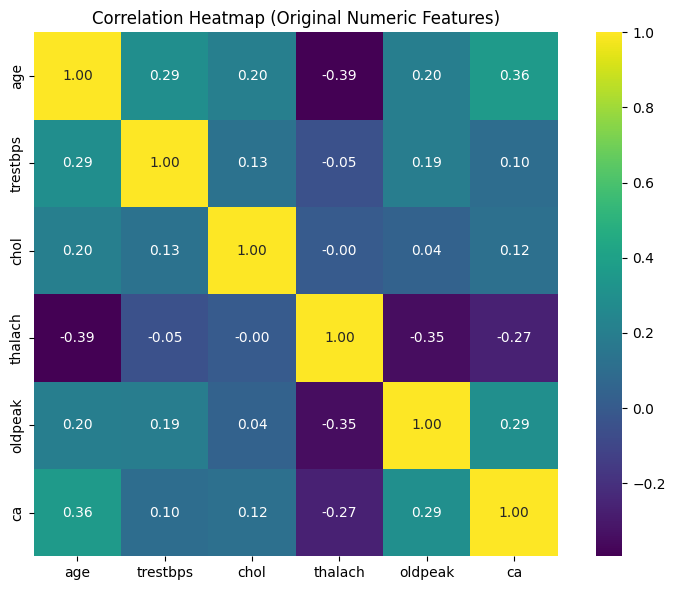

In [33]:
num_features_before_encoding = X.select_dtypes(include=[np.number])
corr = num_features_before_encoding.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", square=True)
plt.title("Correlation Heatmap (Original Numeric Features)")
plt.tight_layout()
plt.show()

### top-3 strongest absolute correlations (excluding diagonal) 

In [34]:
corr_pairs = corr.abs().where(~np.eye(corr.shape[0], dtype=bool)).stack().sort_values(ascending=False)
seen = set() #set so that duplicates donot appear
top3 = []
for (f1, f2), val in corr_pairs.items():
    key = tuple(sorted((f1, f2)))
    if key not in seen:
        seen.add(key)
        top3.append((f1, f2, corr.loc[f1, f2]))
    if len(top3) == 3:
        break

print("Top 3 strongest correlation pairs:")
for i, (f1, f2, v) in enumerate(top3, start=1):
    print(f"{i}. {f1} vs {f2}: {v:.3f}")


Top 3 strongest correlation pairs:
1. thalach vs age: -0.395
2. ca vs age: 0.362
3. thalach vs oldpeak: -0.348


in naive bayes:
Very strong feature correlation can violate the conditional-independence assumption of Naive Bayes,
which may reduce probability calibration and sometimes classification performance.